In [1]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    # The printed text block is 4.5 inches wide.
    "full_landscape": (4.50, 2.65),
    "full_standard": (4.50, 3.15),
    "full_tall": (4.50, 4.20),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "Greys",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
        transform=None,
        bbox=dict(facecolor="white", edgecolor="none", pad=0.8, alpha=0.9),
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Particle Smoothing for the Duffing Oscillator



A particle filter estimates the current latent state from observations available up to the current time. At state time $t_n$, it targets $p(\boldsymbol{x}_n\mid y_{1:n},u_{0:n-1})$. A fixed-interval particle smoother revises that estimate after all $T$ observations are available and targets $p(\boldsymbol{x}_n\mid y_{1:T},u_{0:T-1})$. At the final time $t_T$, the filtering and smoothing distributions coincide.

This example uses backward simulation to smooth a stochastic Duffing trajectory generated with the model of the preceding filtering example. All physical and noise parameters remain fixed; the calculation reconstructs the latent trajectory and does not estimate model parameters.


In [2]:
import importlib.util
import json
import subprocess
import sys
from importlib import metadata

DAX_COMMIT = "084af6da51c95ea0807759022344c3cca07d0a64"
required_packages = {"diffrax": "diffrax", "optax": "optax", "blackjax": "blackjax", "seaborn": "seaborn"}
missing_packages = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

try:
    direct_url = metadata.distribution("dax").read_text("direct_url.json")
    installed_dax_commit = json.loads(direct_url or "{}").get("vcs_info", {}).get("commit_id")
except metadata.PackageNotFoundError:
    installed_dax_commit = None

if installed_dax_commit != DAX_COMMIT:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--no-deps", "--force-reinstall",
        f"git+https://github.com/PredictiveScienceLab/dax.git@{DAX_COMMIT}",
    ])

In [3]:
import dax
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr

jax.config.update("jax_enable_x64", True)
key = jr.PRNGKey(0)


## State-Space Model

The deterministic forced Duffing oscillator is

$$
\ddot{x}+\delta\dot{x}+\alpha x+\beta x^3=\gamma\cos(\omega t).
$$

The parameters $\delta$, $\alpha$, and $\beta$ determine damping and the restoring force; $\omega$ and $\gamma$ are the forcing frequency and amplitude. The stochastic state is $\boldsymbol{X}_t=(X_{1,t},X_{2,t})^{\mathsf T}$, where $X_1$ is position and $X_2$ is a velocity-like state. With the dimensionless control ${u(t)=\cos(\omega t)}$, the Itô model is

$$
\begin{aligned}
dX_{1,t} &= X_{2,t}\,dt+\sigma_x\,dW_{1,t},\\
dX_{2,t} &= [\gamma u(t)-\delta X_{2,t}-\alpha X_{1,t}-\beta X_{1,t}^3]dt+\sigma_v\,dW_{2,t}.
\end{aligned}
$$

The Brownian motions $W_1$ and $W_2$ are independent. Direct Brownian forcing makes $X_1$ nondifferentiable when $\sigma_x>0$, so $X_2$ is not literally $\dot X_1$ in this stochastic model.

Writing $\boldsymbol{x}_n=(x_n,v_n)^{\mathsf T}$, define the Euler--Maruyama mean for the step from $t_n$ to $t_{n+1}=t_n+\Delta t$ as

$$
\boldsymbol{m}_{\Delta t}(x,v,u)=
\begin{bmatrix}
x+v\Delta t\\
v+[\gamma u-\delta v-\alpha x-\beta x^3]\Delta t
\end{bmatrix}.
$$

The transition density evaluated by the smoother is

$$
p(\boldsymbol{x}_{n+1}\mid\boldsymbol{x}_n,u_n)
=\mathcal{N}\!\left(
\boldsymbol{x}_{n+1}\,\middle|\,
\boldsymbol{m}_{\Delta t}(x_n,v_n,u_n),
\Delta t\,\operatorname{diag}(\sigma_x^2,\sigma_v^2)
\right),
$$

where $u_n=u(t_n)$. The factor $\Delta t$ in the covariance is essential because backward simulation evaluates this density between stored filtering particles.


In [4]:
class DuffingControl(dax.ControlFunction):
    omega: jax.Array

    def __init__(self, omega):
        self.omega = jnp.array(omega)

    def _eval(self, t):
        omega = jax.lax.stop_gradient(self.omega)
        return jnp.cos(omega * t)


class Duffing(dax.StochasticDifferentialEquation):
    alpha: jax.Array
    beta: jax.Array
    delta: jax.Array
    gamma: jax.Array
    log_sigma_x: jax.Array
    log_sigma_v: jax.Array

    @property
    def sigma_x(self):
        return jnp.exp(self.log_sigma_x)

    @property
    def sigma_v(self):
        return jnp.exp(self.log_sigma_v)

    def __init__(self, alpha, beta, gamma, delta, sigma_x, sigma_v, u):
        super().__init__(control_function=u)
        self.alpha = jnp.array(alpha)
        self.beta = jnp.array(beta)
        self.delta = jnp.array(delta)
        self.gamma = jnp.array(gamma)
        self.log_sigma_x = jnp.log(sigma_x)
        self.log_sigma_v = jnp.log(sigma_v)

    def drift(self, x, u):
        gamma = jax.lax.stop_gradient(self.gamma)
        return jnp.array([
            x[1],
            gamma * u - self.delta * x[1] - self.alpha * x[0]
            - self.beta * x[0] ** 3,
        ])

    def diffusion(self, x, u):
        sigma_x = jax.lax.stop_gradient(self.sigma_x)
        sigma_v = jax.lax.stop_gradient(self.sigma_v)
        return jnp.array([sigma_x, sigma_v])


class NormalizedGaussianLikelihood(dax.GaussianLikelihood):
    # Gaussian likelihood with its normalizing constant included.

    def _log_prob(self, y, x, u):
        mean = self.observation_function(x, u)
        standardized = (y - mean) / self.sigma
        return -0.5 * jnp.sum(
            standardized**2 + 2.0 * self.log_sigma
            + jnp.log(2.0 * jnp.pi)
        )


class EulerMaruyamaTransition(dax.EulerMaruyama):
    # Euler--Maruyama transition with a normalized Gaussian log density.

    def _log_prob(self, x_next, x_prev, u):
        mean = x_prev + self.sde.drift(x_prev, u) * self.dt
        scale = self.sde.diffusion(x_prev, u) * jnp.sqrt(self.dt)
        standardized = (x_next - mean) / scale
        return -0.5 * jnp.sum(
            standardized**2 + 2.0 * jnp.log(scale)
            + jnp.log(2.0 * jnp.pi)
        )


The numerical experiment fixes $\omega=1.2$, $\alpha=-1$, $\beta=1$, $\delta=0.3$, ${\gamma=0.5}$, $\sigma_x=0.01$, and $\sigma_v=0.05$. The synthetic path starts from $\boldsymbol{X}_0=(1,0)^{\mathsf T}$, while the filter starts from the broad prior $\boldsymbol{X}_0\sim\mathcal{N}(\boldsymbol{0},I_2)$. At every positive state time, the position observation satisfies

$$
Y_n=X_{1,n}+\epsilon_n,
\qquad
\epsilon_n\overset{\mathrm{iid}}{\sim}\mathcal{N}(0,0.1^2).
$$

The velocity-like state remains unobserved, and the observation errors are independent of the process noise and initial state.


In [5]:
omega = 1.2
alpha = -1.0
beta = 1.0
delta = 0.3
gamma = 0.5
sigma_x = 0.01
sigma_v = 0.05

u = DuffingControl(omega)
true_sde = Duffing(alpha, beta, gamma, delta, sigma_x, sigma_v, u)
true_x0 = jnp.array([1.0, 0.0])

observation_function = dax.SingleStateSelector(0)
observation_standard_deviation = 0.1
observation_likelihood = NormalizedGaussianLikelihood(
    observation_standard_deviation, observation_function
)

dt = 0.1
initial_distribution = dax.DiagonalGaussian(
    jnp.array([0.0, 0.0]), jnp.array([1.0, 1.0])
)
ssm = dax.StateSpaceModel(
    initial_distribution,
    EulerMaruyamaTransition(true_sde, dt=dt),
    observation_likelihood,
)


## Synthetic Observations

The latent path is generated over $0\leq t\leq20$ with outputs every ${\Delta t=0.1}$. The path generator uses an internal step of $0.05$, while inference uses one Euler--Maruyama step per observation interval. Measurements are generated only at the positive times $t_1,\ldots,t_{200}$. The associated controls $u_0,\ldots,u_{199}$ are evaluated at the left endpoints of those transitions.


In [6]:
t0 = 0.0
t1 = 20.0

key, path_key, observation_key = jr.split(key, 3)
solution = true_sde.sample_path(
    path_key, t0, t1, true_x0, dt=dt, dt0=0.05
)
xs = solution.ys
ts = solution.ts
us = u(ts)

observation_keys = jr.split(observation_key, xs.shape[0] - 1)
ys = observation_likelihood.sample(
    xs[1:], us[:-1], observation_keys
)
ts_obs = ts[1:]
us_filter = us[:-1]


## Backward Simulation

The bootstrap filter first stores particles $\boldsymbol{x}_n^{(i)}$ and normalized weights $w_n^{(i)}$ for every state time. To draw one smoothed trajectory, backward simulation selects a terminal particle according to the filtering weights at $t_{200}$. If the next selected state is $\boldsymbol{x}_{n+1}^{\star}$, particle $i$ at time $t_n$ receives the unnormalized backward weight

$$
\widetilde b_n^{(i)}
=w_n^{(i)}
p(\boldsymbol{x}_{n+1}^{\star}\mid\boldsymbol{x}_n^{(i)},u_n).
$$

Normalizing these weights and drawing an ancestor produces the preceding state. The observation likelihood does not appear separately: $w_n^{(i)}$ already contains the observations through $t_n$, and the selected next state carries the effect of later observations backward through the transition density. Repeating the step to $t_0$ gives one trajectory from the particle approximation to $p(\boldsymbol{x}_{0:200}\mid y_{1:200},u_{0:199})$. The implementation repeats the backward pass 1,000 times. The transition density therefore affects every backward draw, even though the bootstrap filter itself only needs transition samples.


In [7]:
class IndependentKeyBootstrapFilter(dax.BootstrapFilter):
    # Bootstrap filter with separate resampling and propagation keys.

    @eqx.filter_jit
    def filter(self, ssm, controls, observations, key):
        def step(carry, control_observation):
            pa, step_key, log_likelihood = carry
            control, observation = control_observation
            step_key, resampling_key, propagation_key = jr.split(
                step_key, 3
            )
            resampled_pa = pa.resample(resampling_key)
            particle_keys = jr.split(
                propagation_key, self.num_particles
            )
            particles_next = ssm.transition.sample(
                resampled_pa.particles, control, particle_keys
            )
            log_weights_next = ssm.likelihood.log_prob(
                observation, particles_next, control
            )
            log_increment = (
                jax.scipy.special.logsumexp(log_weights_next)
                - jnp.log(self.num_particles)
            )
            pa_next = dax.ParticleApproximation(
                particles_next, log_weights_next
            ).normalize()
            return (
                pa_next,
                step_key,
                log_likelihood + log_increment,
            ), pa_next

        key, initial_key = jr.split(key)
        initial_keys = jr.split(initial_key, self.num_particles)
        pa0 = dax.ParticleApproximation(ssm.x0.sample(initial_keys))
        initial = (pa0, key, jnp.array(0.0))
        (_, _, log_likelihood), pas_rest = jax.lax.scan(
            step, initial, (controls, observations)
        )
        pas = dax.TrajectoryParticleApproximation.make_from_init_and_rest(
            pa0, pas_rest
        )
        return pas, log_likelihood


num_particles = 10_000
particle_filter = IndependentKeyBootstrapFilter(
    num_particles=num_particles
)
key, filter_key, filter_interval_key, smoother_key = jr.split(key, 4)
filtering_particles, log_marginal_likelihood = particle_filter.filter(
    ssm, us_filter, ys, filter_key
)
filter_lower, filter_median, filter_upper = (
    filtering_particles.get_credible_interval(filter_interval_key)
)

num_smoothing_trajectories = 1_000
particle_smoother = dax.BootstrapSmoother(
    num_smoothing_trajectories
)
smoothed_trajectories = particle_smoother.smooth(
    ssm, filtering_particles, us_filter, ys, smoother_key
)
smooth_lower, smooth_median, smooth_upper = (
    smoothed_trajectories.get_credible_interval()
)

filter_rmse = jnp.sqrt(jnp.mean((filter_median - xs) ** 2, axis=0))
smooth_rmse = jnp.sqrt(jnp.mean((smooth_median - xs) ** 2, axis=0))
early = ts <= 1.0
early_filter_rmse = jnp.sqrt(
    jnp.mean((filter_median[early] - xs[early]) ** 2, axis=0)
)
early_smooth_rmse = jnp.sqrt(
    jnp.mean((smooth_median[early] - xs[early]) ** 2, axis=0)
)
terminal_median_difference = jnp.abs(
    filter_median[-1] - smooth_median[-1]
)

print(f"Estimated log marginal likelihood: {float(log_marginal_likelihood):.1f}")
print(
    "Full-interval median RMSE (filter -> smoother): "
    f"position {float(filter_rmse[0]):.3f} -> {float(smooth_rmse[0]):.3f}; "
    "velocity-like state "
    f"{float(filter_rmse[1]):.3f} -> {float(smooth_rmse[1]):.3f}"
)
print(
    "Early-interval median RMSE, 0 <= t <= 1 (filter -> smoother): "
    f"position {float(early_filter_rmse[0]):.3f} -> {float(early_smooth_rmse[0]):.3f}; "
    "velocity-like state "
    f"{float(early_filter_rmse[1]):.3f} -> {float(early_smooth_rmse[1]):.3f}"
)
print(
    "Absolute terminal-median difference from finite Monte Carlo samples: "
    f"position={float(terminal_median_difference[0]):.4f}, "
    f"velocity-like state={float(terminal_median_difference[1]):.4f}"
)


Estimated log marginal likelihood: 148.8
Full-interval median RMSE (filter -> smoother): position 0.081 -> 0.024; velocity-like state 0.096 -> 0.042
Early-interval median RMSE, 0 <= t <= 1 (filter -> smoother): position 0.305 -> 0.011; velocity-like state 0.215 -> 0.030
Absolute terminal-median difference from finite Monte Carlo samples: position=0.0005, velocity-like state=0.0021


## Filtering and Smoothing Comparison

The filtering median at time $t_n$ uses $Y_1,\ldots,Y_n$. The smoothing median at the same time uses the complete record $Y_1,\ldots,Y_{200}$. Both are componentwise summaries of marginal state distributions. The comparison in {numref}`fig-duffing-particle-smoother-full` shows the full interval; the following enlarged view isolates the initial transient, where later observations can substantially revise the diffuse initial estimate.


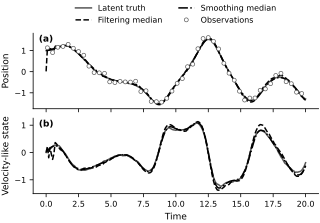

In [8]:
fig, ax = new_figure(
    size="full_standard", nrows=2, ncols=1, sharex=True
)

for state_index in range(2):
    ax[state_index].plot(
        ts, xs[:, state_index], color="0.35", linestyle="-",
        label="Latent truth" if state_index == 0 else None,
    )
    ax[state_index].plot(
        ts, filter_median[:, state_index], color="black",
        linestyle="--", label="Filtering median" if state_index == 0 else None,
    )
    ax[state_index].plot(
        ts, smooth_median[:, state_index], color="black",
        linestyle="-.", label="Smoothing median" if state_index == 0 else None,
    )

ax[0].plot(
    ts_obs, ys, linestyle="none", marker="o", markevery=4,
    markerfacecolor="white", markeredgecolor="0.35",
    markeredgewidth=0.7, label="Observations",
)
ax[0].set_ylabel("Position")
ax[0].legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2
)
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Velocity-like state")
label_panels(ax)
finalize_axes(ax)
plt.show()


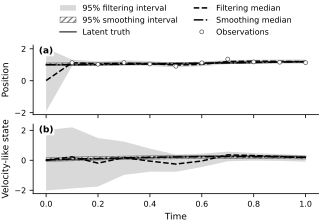

In [9]:
early_time = ts <= 1.0
early_observations = ts_obs <= 1.0

fig, ax = new_figure(
    size="full_standard", nrows=2, ncols=1, sharex=True
)

for state_index in range(2):
    ax[state_index].fill_between(
        ts[early_time],
        filter_lower[early_time, state_index],
        filter_upper[early_time, state_index],
        facecolor="0.85", edgecolor="none",
        label="95% filtering interval" if state_index == 0 else None,
    )
    ax[state_index].fill_between(
        ts[early_time],
        smooth_lower[early_time, state_index],
        smooth_upper[early_time, state_index],
        facecolor="none", edgecolor="0.35", linewidth=0.5,
        hatch="////",
        label="95% smoothing interval" if state_index == 0 else None,
    )
    ax[state_index].plot(
        ts[early_time], xs[early_time, state_index],
        color="0.35", linestyle="-",
        label="Latent truth" if state_index == 0 else None,
    )
    ax[state_index].plot(
        ts[early_time], filter_median[early_time, state_index],
        color="black", linestyle="--",
        label="Filtering median" if state_index == 0 else None,
    )
    ax[state_index].plot(
        ts[early_time], smooth_median[early_time, state_index],
        color="black", linestyle="-.",
        label="Smoothing median" if state_index == 0 else None,
    )

ax[0].plot(
    ts_obs[early_observations], ys[early_observations],
    linestyle="none", marker="o", markerfacecolor="white",
    markeredgecolor="0.35", markeredgewidth=0.7,
    label="Observations",
)
ax[0].set_ylabel("Position")
ax[0].legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2
)
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Velocity-like state")
label_panels(ax)
finalize_axes(ax)
plt.show()


In this realization, smoothing improves the median reconstruction most clearly near the beginning of the record, where the filter begins from a diffuse prior. The smoother uses observations on both sides of an early state, while the filter can use only observations already received. The improvement is realization-dependent: smoothing changes the conditioning information, but it does not guarantee a smaller pointwise error at every time.

The phase portrait in {numref}`fig-duffing-particle-smoother-phase` combines both state components. Several backward-sampled paths show the joint smoothing approximation and retain dependence across time. The connected median curves are pointwise componentwise summaries; they are not themselves sampled trajectories from the dynamic model.


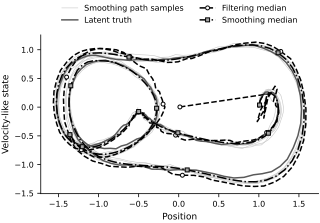

In [10]:
fig, ax = new_figure(size="full_standard")
for sample_index in range(6):
    ax.plot(
        smoothed_trajectories.samples[sample_index, :, 0],
        smoothed_trajectories.samples[sample_index, :, 1],
        color="0.78", linewidth=0.6, linestyle="-",
        label="Smoothing path samples" if sample_index == 0 else None,
    )
ax.plot(
    xs[:, 0], xs[:, 1], color="0.35", linestyle="-",
    label="Latent truth",
)
ax.plot(
    filter_median[:, 0], filter_median[:, 1], color="black",
    linestyle="--", marker="o", markevery=20,
    markerfacecolor="white", markeredgecolor="black",
    label="Filtering median",
)
ax.plot(
    smooth_median[:, 0], smooth_median[:, 1], color="black",
    linestyle="-.", marker="s", markevery=20,
    markerfacecolor="0.65", markeredgecolor="black",
    label="Smoothing median",
)
ax.set_xlabel("Position")
ax.set_ylabel("Velocity-like state")
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2
)
finalize_axes(ax)
plt.show()


The smoothing trajectories are joint paths, so they retain temporal dependence across state times. Pointwise credible intervals summarize each marginal smoothing distribution separately and do not form a simultaneous credible band for an entire trajectory.

The next section treats model calibration, where one or more Duffing parameters are unknown rather than fixed.

## Exercises

1. Derive the normalized backward weights from $\widetilde b_n^{(i)}$. Explain why the observation likelihood at $t_{n+1}$ does not appear explicitly in this backward step.
2. Increase and decrease the number of backward trajectories while holding the filtering particles and random seed fixed. Compare the Monte Carlo variability of the smoothing median and credible intervals.
3. Repeat the experiment with a larger observation standard deviation. Compare filtering and smoothing RMSE over the full interval and over $0\leq t\leq1$.
4. Verify numerically that filtering and smoothing target the same distribution at the final state time. Explain why their finite-sample summaries need not be exactly equal.
